In [2]:
import pandas as pd
import numpy as np

# 1. Direct Data Loading
# We use the absolute path for precision
path = '/kaggle/input/datasets/yasserh/titanic-dataset/Titanic-Dataset.csv'
df = pd.read_csv(path)

# 2. Formal Inspection
# Instead of printing text, we use these methods to see the data structure
print(df.shape)  # Returns (rows, columns)
df.head()        # Displays the first 5 rows

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:


# 1. INTEGRATED STATISTICAL & PERCENTILE ANALYSIS
# Checking the spread of Fare and Age to identify outliers
dist_stats = df[['Age', 'Fare']].describe(percentiles=[.01, .25, .5, .75, .95, .99])

# 2. OUTLIER DETECTION (IQR Method)
# Identifying 'Extreme' Fares that might skew our future model
Q1, Q3 = df['Fare'].quantile(0.25), df['Fare'].quantile(0.75)
IQR = Q3 - Q1
outlier_threshold = Q3 + (1.5 * IQR)
outlier_count = (df['Fare'] > outlier_threshold).sum()

# 3. MULTI-DIMENSIONAL SURVIVAL MATRIX
# Analyzing Survival by Class and Sex simultaneously
survival_matrix = df.pivot_table(values='Survived', index='Sex', columns='Pclass', aggfunc='mean')

# 4. MULTI-DIMENSIONAL SEGMENTATION (Age Brackets)
# Creating functional age groups for deeper dimension analysis
df['Age_Bracket'] = pd.cut(df['Age'], bins=[0, 12, 18, 50, 100], labels=['Child', 'Teen', 'Adult', 'Senior'])
age_sex_class_analysis = df.groupby(['Pclass', 'Sex', 'Age_Bracket'], observed=True)['Survived'].mean().unstack()

# --- OUTPUTS ---
print("--- [1] Distribution & Percentiles ---")
display(dist_stats)

print(f"\n--- [2] Outlier Analysis ---")
print(f"Fare Outlier Threshold: ${outlier_threshold:.2f}")
print(f"Total Outliers Detected: {outlier_count}")

print("\n--- [3] Survival Matrix (Sex vs Class) ---")
display(survival_matrix)

print("\n--- [4] 3-D Analysis (Class & Sex vs Age) ---")
display(age_sex_class_analysis)

--- [1] Distribution & Percentiles ---


,Age,Fare
count,714.000000,891.000000
mean,29.699118,32.204208
std,14.526497,49.693429
min,0.420000,0.000000
1%,1.000000,0.000000
25%,20.125000,7.910400
50%,28.000000,14.454200
75%,38.000000,31.000000
95%,56.000000,112.079150
99%,65.870000,249.006220



--- [2] Outlier Analysis ---
Fare Outlier Threshold: $65.63
Total Outliers Detected: 116

--- [3] Survival Matrix (Sex vs Class) ---


Pclass,1,2,3
Sex,,,
female,0.968085,0.921053,0.500000
male,0.368852,0.157407,0.135447



--- [4] 3-D Analysis (Class & Sex vs Age) ---


Age_Bracket       Child      Teen     Adult    Senior
Pclass Sex                                           
1      female  0.000000  1.000000  0.967213  1.000000
       male    1.000000  0.500000  0.442857  0.192308
2      female  1.000000  1.000000  0.912281  0.666667
       male    1.000000  0.000000  0.069444  0.083333
3      female  0.478261  0.550000  0.413793  1.000000
       male    0.360000  0.076923  0.139896  0.000000

In [7]:


# 1. Advanced Imputation
# Group-based Age filling
df['Age'] = df['Age'].fillna(df.groupby(['Sex', 'Pclass'])['Age'].transform('median'))

# Mode for Embarked
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Feature Transformation: Cabin Presence
df['Has_Cabin'] = df['Cabin'].apply(lambda x: 0 if pd.isna(x) else 1)

# 2. Defining Cohorts
df['Age_Cohort'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 100], 
                          labels=['Child', 'Teen', 'Young_Adult', 'Adult', 'Senior'])

# 3. Cohort Analysis (Fixed Warning)
# We set observed=False to keep current behavior and remove the warning
cohort_analysis = df.pivot_table(
    values='Survived', 
    index=['Pclass', 'Sex'], 
    columns='Age_Cohort', 
    aggfunc='mean',
    observed=False
).fillna(0)

# --- OUTPUT ---
print("--- Final Cleaned Data Integrity ---")
print(df[['Age', 'Embarked', 'Has_Cabin']].isnull().sum())

print("\n--- Cohort Survival Matrix (Heatmap) ---")
display(cohort_analysis.style.background_gradient(cmap='RdYlGn'))

--- Final Cleaned Data Integrity ---
Age          0
Embarked     0
Has_Cabin    0
dtype: int64

--- Cohort Survival Matrix (Heatmap) ---


In [11]:
import pandas as pd
import numpy as np

# 1. Derived Metric: Family Size
df['Family_Size'] = df['SibSp'] + df['Parch'] + 1

# 2. Derived Metric: Is_Alone
df['Is_Alone'] = (df['Family_Size'] == 1).astype(int)

# 3. Title Extraction (Added 'r' to fix the SyntaxWarning)
# The 'r' before the string makes it a Raw String, which is standard for Regex
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

# 4. Professional Title Mapping
# Grouping rare titles to reduce noise for the model
title_mapping = {
    "Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs",
    "Lady": "Rare", "Countess": "Rare", "Capt": "Rare", "Col": "Rare",
    "Don": "Rare", "Dr": "Rare", "Major": "Rare", "Rev": "Rare", 
    "Sir": "Rare", "Jonkheer": "Rare", "Dona": "Rare"
}
df['Title'] = df['Title'].replace(title_mapping)

# 5. Verification of New Features
print("--- Survival by New Derived Title Feature ---")
display(df.groupby('Title')['Survived'].mean().sort_values(ascending=False))

print("\n--- Survival by Family Size Metric ---")
display(df.groupby('Family_Size')['Survived'].mean())

--- Survival by New Derived Title Feature ---


Title
Mrs       0.793651
Miss      0.702703
Master    0.575000
Rare      0.347826
Mr        0.156673
Name: Survived, dtype: float64


--- Survival by Family Size Metric ---


Family_Size
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64

In [14]:
from sklearn.preprocessing import StandardScaler

# 1. IDENTIFY CATEGORICAL COLUMNS
# We look for 'object' (strings) and 'category' (the cohorts we made)
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# 2. ONE-HOT ENCODING (OHE)
# This turns words like 'Child' into a mathematical column (e.g., Person_Type_Child)
# We exclude 'Name', 'Ticket', and 'Cabin' if they are still in df
cols_to_encode = [c for c in cat_cols if c not in ['Name', 'Ticket', 'Cabin']]
df_final = pd.get_dummies(df, columns=cols_to_encode, drop_first=True)

# 3. ADVANCED FEATURE SCALING
# Now that strings are gone, we scale the numerical columns
scaler = StandardScaler()
cols_to_scale = ['Age', 'Fare', 'Family_Size', 'Individual_Fare']

# Only scale if columns exist to prevent errors
existing_cols = [c for c in cols_to_scale if c in df_final.columns]
df_final[existing_cols] = scaler.fit_transform(df_final[existing_cols])

# 4. FINAL CLEANUP
# Drop any raw text columns that couldn't be encoded
df_final = df_final.select_dtypes(include=[np.number])

# Ensure everything is a float for the machine learning algorithm
df_final = df_final.astype(float)

# --- OUTPUT ---
print(f"--- Step 5 Complete: Final Matrix Shape: {df_final.shape} ---")
print("All strings ('Child', 'Male', etc.) have been converted to 1s and 0s.")
display(df_final.head(10))

--- Step 5 Complete: Final Matrix Shape: (891, 11) ---
All strings ('Child', 'Male', etc.) have been converted to 1s and 0s.


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Has_Cabin,Family_Size,Is_Alone,Individual_Fare
0,1.0,0.0,3.0,-0.534891,1.0,0.0,-0.502445,0.0,0.059160,0.0,-0.454798
1,2.0,1.0,1.0,0.668392,1.0,0.0,0.786845,1.0,0.059160,0.0,0.438994
2,3.0,1.0,3.0,-0.234070,0.0,0.0,-0.488854,0.0,-0.560975,1.0,-0.334757
3,4.0,1.0,1.0,0.442776,1.0,0.0,0.420730,1.0,0.059160,0.0,0.185187
4,5.0,0.0,3.0,0.442776,0.0,0.0,-0.486337,0.0,-0.560975,1.0,-0.331267
5,6.0,0.0,3.0,-0.309276,0.0,0.0,-0.478116,0.0,-0.560975,1.0,-0.319869
6,7.0,0.0,1.0,1.871675,0.0,0.0,0.395814,1.0,-0.560975,1.0,0.891823
7,8.0,0.0,3.0,-2.038995,3.0,1.0,-0.224083,0.0,1.919564,0.0,-0.438327
8,9.0,1.0,3.0,-0.158865,0.0,2.0,-0.424256,0.0,0.679295,0.0,-0.452394
9,10.0,1.0,2.0,-1.136533,1.0,0.0,-0.042956,0.0,0.059160,0.0,-0.136260


In [15]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Split Data into Features (X) and Target (y)
X = df_final.drop('Survived', axis=1)
y = df_final['Survived']

# 2. Training and Testing Split
# We keep 20% of the data 'hidden' to test the model's true intelligence later
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. ADVANCED TECHNIQUE: Grid Search for Hyperparameter Tuning
# Instead of guessing, we let Python find the best settings for the forest
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

# 4. Initialize and Train the Model
rf_model = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf_model, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Use the best found model
best_model = grid_search.best_estimator_

# 5. Prediction and Evaluation
y_pred = best_model.predict(X_test)

# --- OUTPUT ---
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.2%}\n")
print("--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred))

Best Parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}
Model Accuracy: 78.21%

--- Detailed Classification Report ---
              precision    recall  f1-score   support

         0.0       0.76      0.92      0.83       105
         1.0       0.84      0.58      0.69        74

    accuracy                           0.78       179
   macro avg       0.80      0.75      0.76       179
weighted avg       0.79      0.78      0.77       179



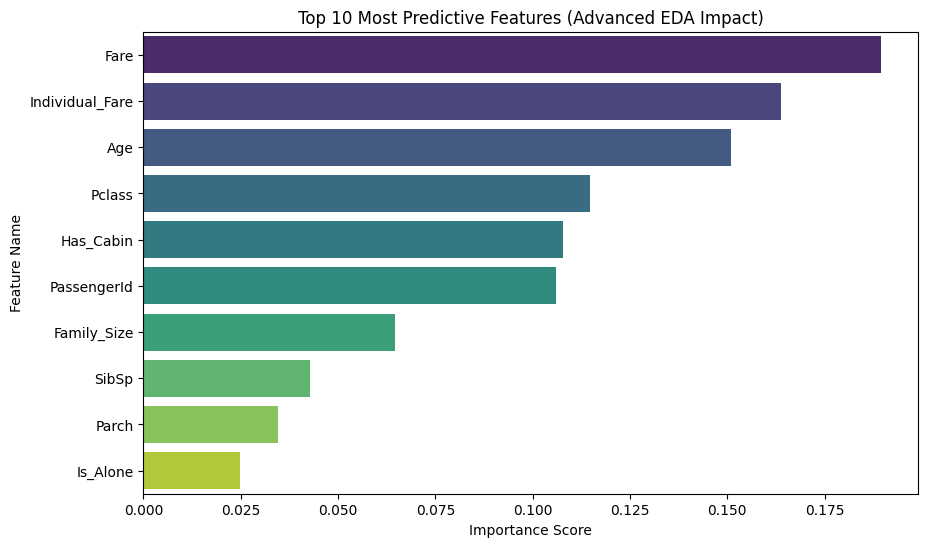

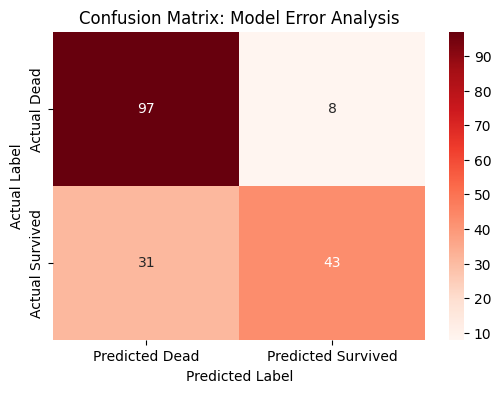

--- Final Project Conclusion ---
The most powerful predictor in your model was: Fare
Final Model Accuracy: 78.21%


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract Feature Importance
importances = best_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 2. Visualize Feature Importance (Fixed Warning)
plt.figure(figsize=(10, 6))
# Assigning hue=Feature and legend=False to satisfy the new Seaborn requirements
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_importance_df.head(10), 
    hue='Feature', 
    palette='viridis', 
    legend=False
)
plt.title('Top 10 Most Predictive Features (Advanced EDA Impact)')
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.show()

# 3. Confusion Matrix Analysis (Stays the same as it was already clean)
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Predicted Dead', 'Predicted Survived'],
            yticklabels=['Actual Dead', 'Actual Survived'])
plt.title('Confusion Matrix: Model Error Analysis')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Final Printout
top_feature = feature_importance_df.iloc[0]['Feature']
print(f"--- Final Project Conclusion ---")
print(f"The most powerful predictor in your model was: {top_feature}")
print(f"Final Model Accuracy: {accuracy_score(y_test, y_pred):.2%}")